In [40]:
# Loading of dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# ==========================================================
# 1 DATA LOADING
# ==========================================================

df = pd.read_csv("/content/credit_card_cleaned.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...          0          0          0         0       689         0   
1  ...       3272       3455       3261         0      1000      1000   
2  ...      14331      14948      15549      1518      1500      1000   
3  ...      28314      28959      29547      2000      2019      1200   
4  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  DEFAULT  
0         0     

In [11]:
# Data Cleaning
df = df.drop_duplicates()

# Check missing values
print("\nMissing Values")
print(df.isnull().sum())

# Fill missing values using median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Rename column for easier use
df.rename(columns={'default payment next month':'DEFAULT'}, inplace=True)

# Drop ID column if present
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

# Correct invalid categorical values
df['EDUCATION'] = df['EDUCATION'].replace([0,5,6],4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0,3)

# Convert categorical columns
categorical_columns = ['SEX','EDUCATION','MARRIAGE','DEFAULT']

for col in categorical_columns:
    df[col] = df[col].astype("category")

print("\nDataset After Cleaning:", df.shape)



Missing Values
ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

Dataset After Cleaning: (30000, 24)


In [15]:
# Feature engineering
df['TOTAL_BILL'] = (
    df['BILL_AMT1'] + df['BILL_AMT2'] + df['BILL_AMT3'] +
    df['BILL_AMT4'] + df['BILL_AMT5'] + df['BILL_AMT6']
)

# Total Payment Amount
df['TOTAL_PAYMENT'] = (
    df['PAY_AMT1'] + df['PAY_AMT2'] + df['PAY_AMT3'] +
    df['PAY_AMT4'] + df['PAY_AMT5'] + df['PAY_AMT6']
)

# Credit Utilization Ratio
df['CREDIT_UTILIZATION'] = df['TOTAL_BILL'] / df['LIMIT_BAL']

# Payment Delay Score
df['PAYMENT_DELAY_SCORE'] = (
    df['PAY_1'] + df['PAY_2'] + df['PAY_3'] +
    df['PAY_4'] + df['PAY_5'] + df['PAY_6']
)

# Risk Score
df['RISK_SCORE'] = df['PAYMENT_DELAY_SCORE'] + df['CREDIT_UTILIZATION']

# Risk Category
def risk_category(score):
    if score <= 0:
        return "Low Risk"
    elif score <= 4:
        return "Medium Risk"
    else:
        return "High Risk"

df['RISK_LEVEL'] = df['PAYMENT_DELAY_SCORE'].apply(risk_category)

print(df[['RISK_SCORE','RISK_LEVEL']].head())

# ==========================================================
# 4 BASIC STATISTICS
# ==========================================================

print(df.describe())


   RISK_SCORE   RISK_LEVEL
0   -1.614800     Low Risk
1    3.142308  Medium Risk
2    1.129478     Low Risk
3    4.626680     Low Risk
4    0.186780     Low Risk
            LIMIT_BAL           AGE         PAY_1         PAY_2         PAY_3  \
count    30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean    167484.322667     35.485500     -0.016700     -0.133767     -0.166200   
std     129747.661567      9.217904      1.123802      1.197186      1.196868   
min      10000.000000     21.000000     -2.000000     -2.000000     -2.000000   
25%      50000.000000     28.000000     -1.000000     -1.000000     -1.000000   
50%     140000.000000     34.000000      0.000000      0.000000      0.000000   
75%     240000.000000     41.000000      0.000000      0.000000      0.000000   
max    1000000.000000     79.000000      8.000000      8.000000      8.000000   

              PAY_4         PAY_5         PAY_6      BILL_AMT1      BILL_AMT2  \
count  30000.000000  30000.

In [97]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

df["TOTAL_BILL"] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']].sum(axis=1)

df["TOTAL_PAYMENT"] = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']].sum(axis=1)

df["UTILIZATION_RATIO"] = df["TOTAL_BILL"] / (df["LIMIT_BAL"] + 1)

df["PAYMENT_RATIO"] = df["TOTAL_PAYMENT"] / (df["TOTAL_BILL"] + 1)

df["DELAY_SCORE"] = df[['PAY_1','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].sum(axis=1)

df["AVG_BILL"] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']].mean(axis=1)

df["AVG_PAYMENT"] = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']].mean(axis=1)

# ==========================================================
# FEATURES AND TARGET
# ==========================================================

X = df.drop(['DEFAULT','RISK_LEVEL'], axis=1, errors='ignore')
y = df['DEFAULT']

# Convert categorical variables
X = pd.get_dummies(X, drop_first=True)

# ==========================================================
# TRAIN TEST SPLIT (test_size = 0.25)
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=30,
    stratify=y
)

# ==========================================================
# ADVANCED RANDOM FOREST MODEL
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=1000,                # stronger ensemble
    max_depth=28,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features="log2",              # improves tree diversity
    bootstrap=True,
    oob_score=True,                   # out-of-bag validation
    class_weight="balanced_subsample",
    random_state=50,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("OOB Score:", rf_model.oob_score_)

# ==========================================================
# PREDICTIONS
# ==========================================================

y_pred = rf_model.predict(X_test)

# ==========================================================
# MODEL EVALUATION
# ==========================================================

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

OOB Score: 0.8116888888888889
Accuracy: 0.818

Confusion Matrix
[[5425  416]
 [ 949  710]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      5841
           1       0.63      0.43      0.51      1659

    accuracy                           0.82      7500
   macro avg       0.74      0.68      0.70      7500
weighted avg       0.80      0.82      0.80      7500



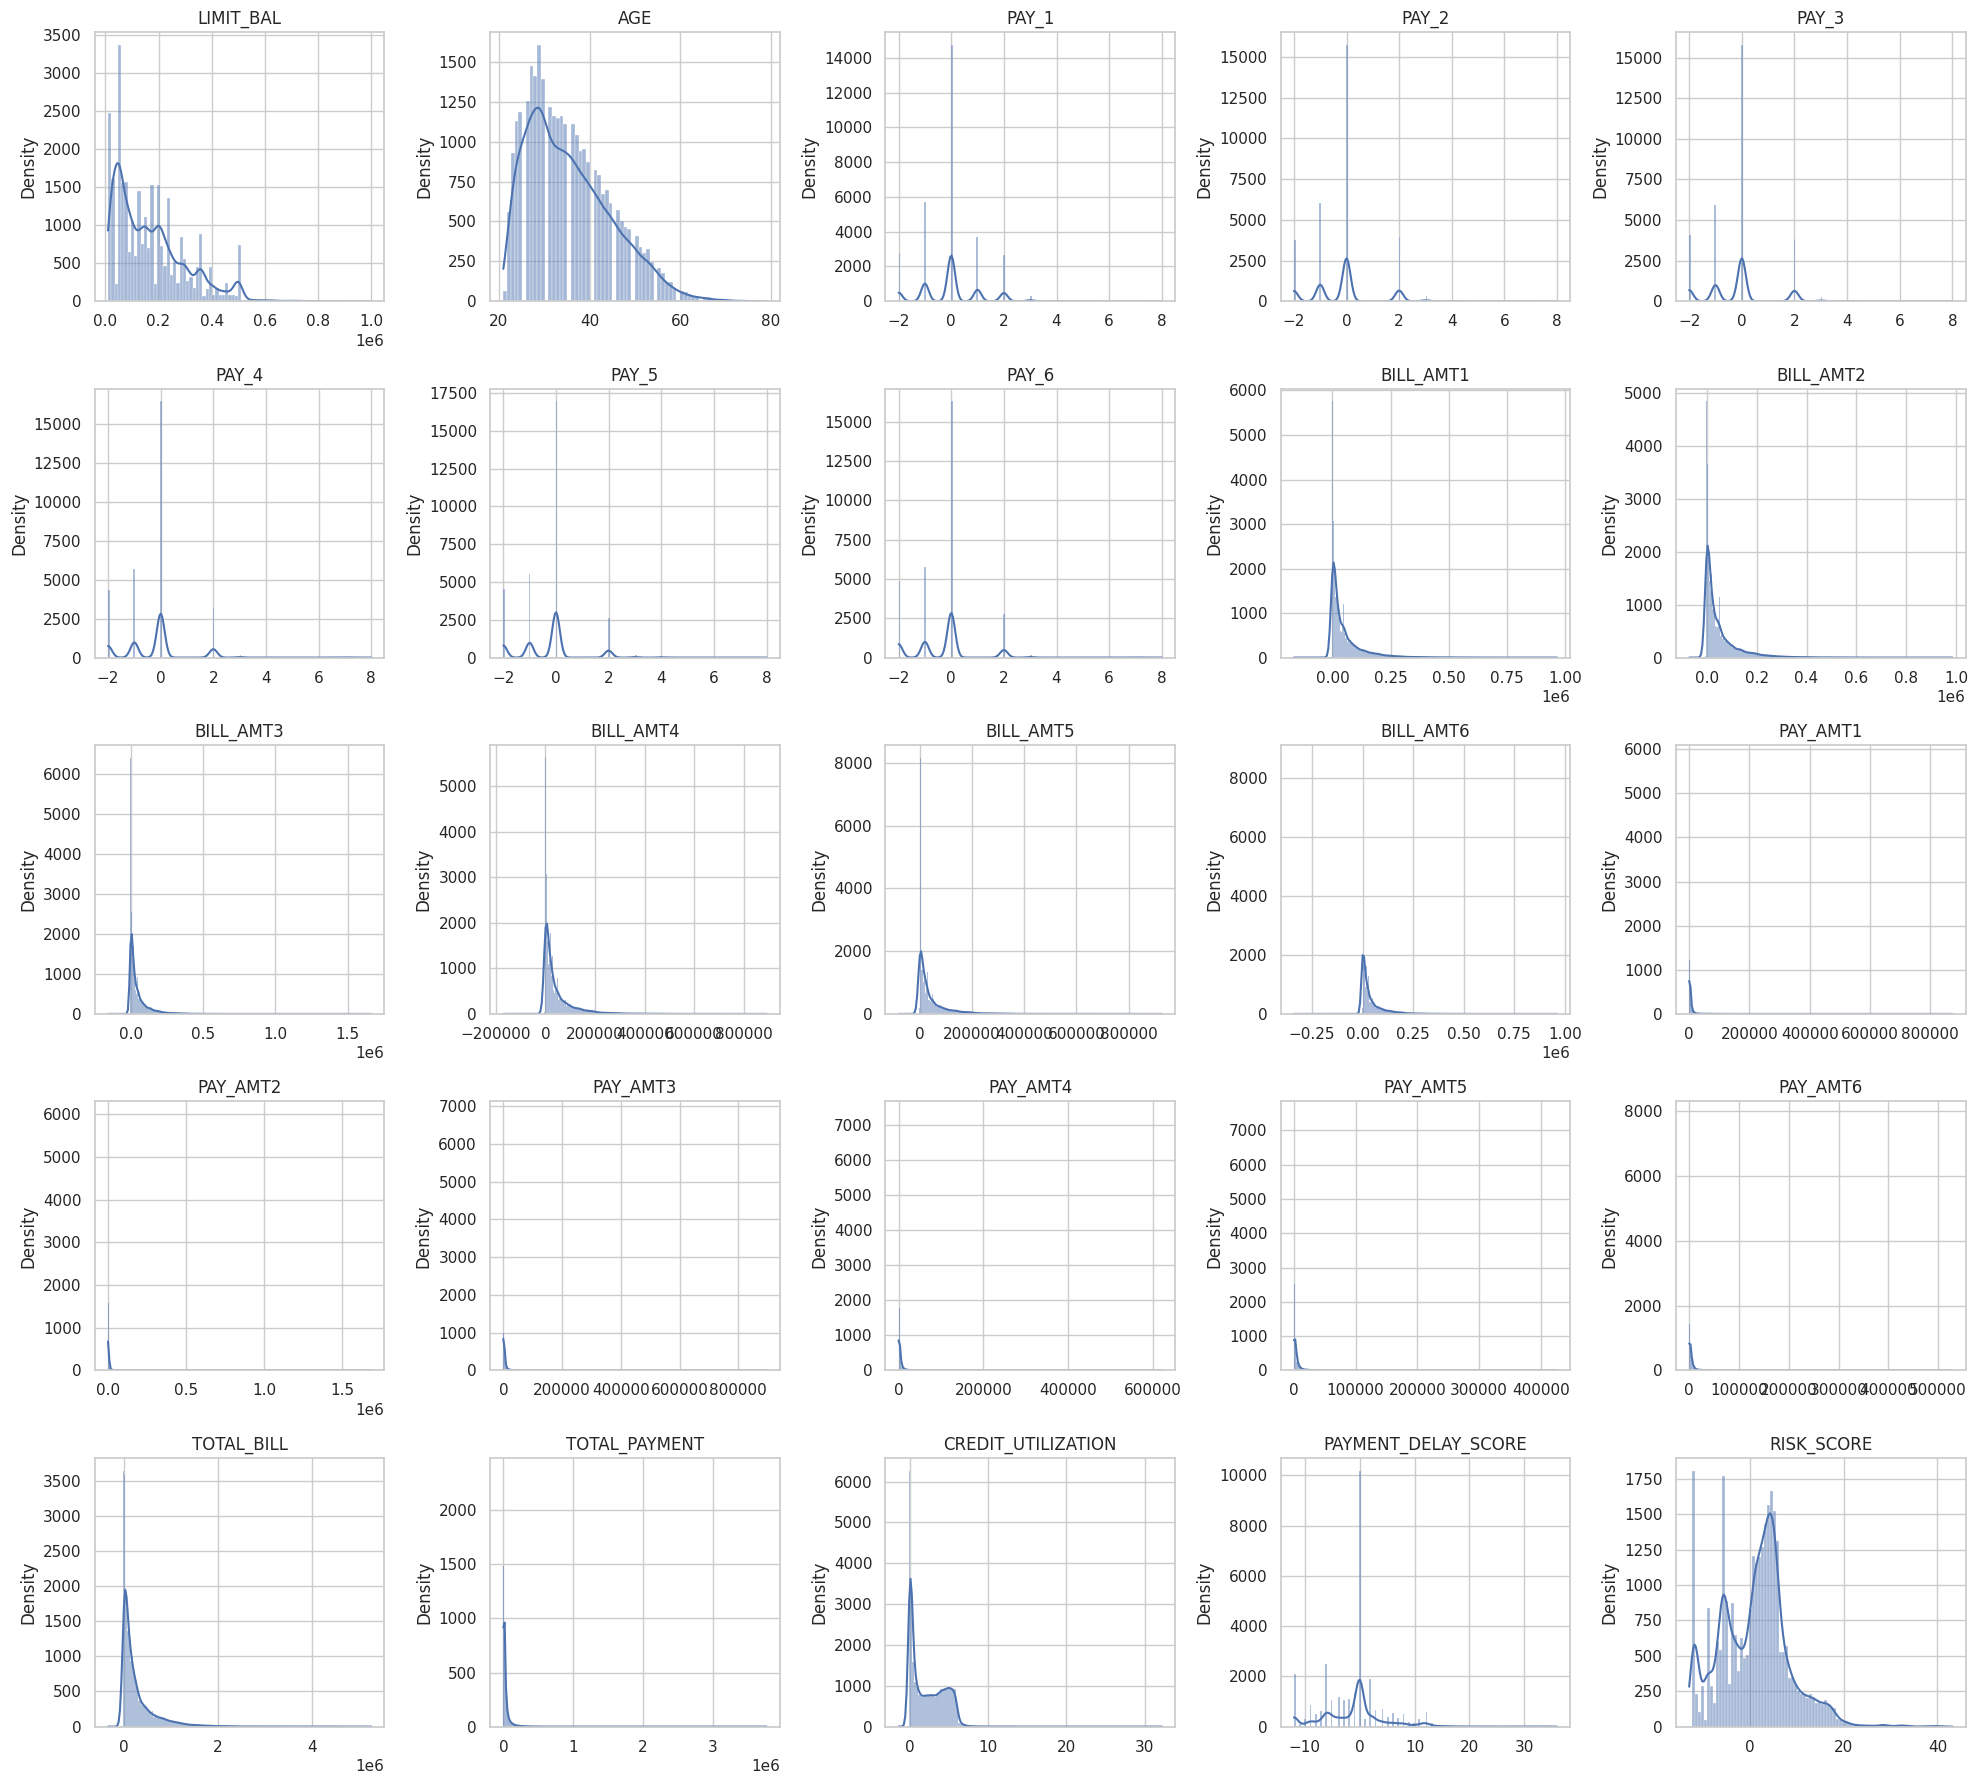

Skewness of each feature:

PAY_AMT2               30.453817
PAY_AMT3               17.216635
PAY_AMT1               14.668364
TOTAL_PAYMENT          14.616877
PAY_AMT4               12.904985
PAY_AMT5               11.127417
PAY_AMT6               10.640727
BILL_AMT3               3.087830
BILL_AMT5               2.876380
BILL_AMT6               2.846645
BILL_AMT4               2.821965
TOTAL_BILL              2.734744
BILL_AMT2               2.705221
BILL_AMT1               2.663861
PAY_5                   1.008197
PAY_4                   0.999629
LIMIT_BAL               0.992867
PAY_6                   0.948029
PAY_3                   0.840682
PAY_2                   0.790565
AGE                     0.732246
PAY_1                   0.731975
PAYMENT_DELAY_SCORE     0.692165
CREDIT_UTILIZATION      0.665967
RISK_SCORE              0.357082
dtype: float64


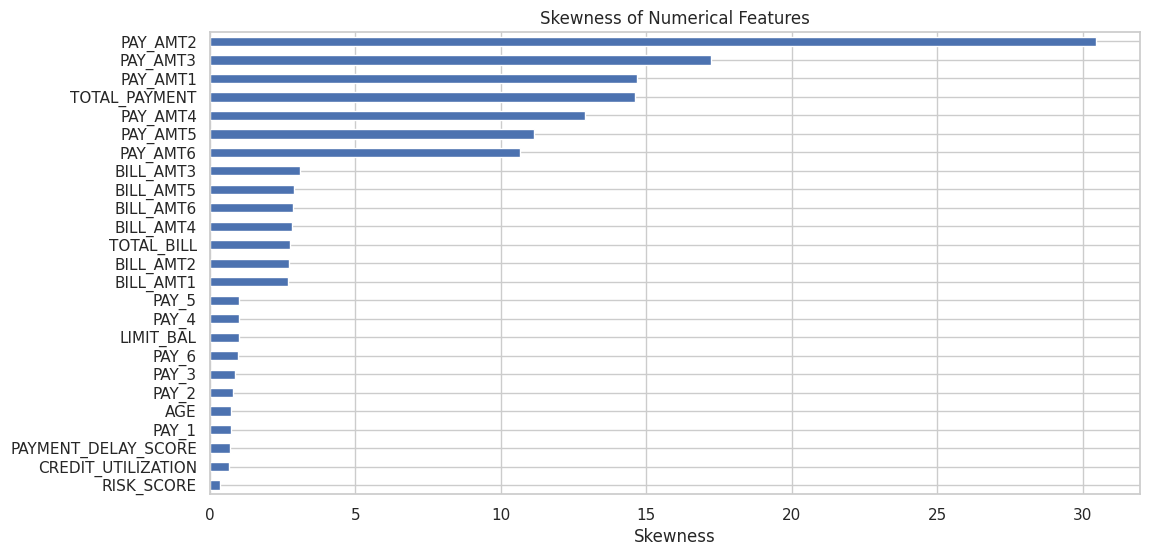

In [32]:
# Skewness
# Exclude the RF_PREDICTION column as it's a model output and not a feature for skewness analysis
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.drop('RF_PREDICTION', errors='ignore')

# Plot size similar to notebook
plt.figure(figsize=(20,18))

for i, col in enumerate(numeric_cols):

    plt.subplot(5,5,i+1)

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)
    plt.xlabel("")
    plt.ylabel("Density")

plt.tight_layout()
plt.show()
skew_values = df[numeric_cols].skew()

print("Skewness of each feature:\n")
print(skew_values.sort_values(ascending=False))

plt.figure(figsize=(12,6))

skew_values.sort_values().plot(
    kind="barh"
)

plt.title("Skewness of Numerical Features")
plt.xlabel("Skewness")
plt.show()

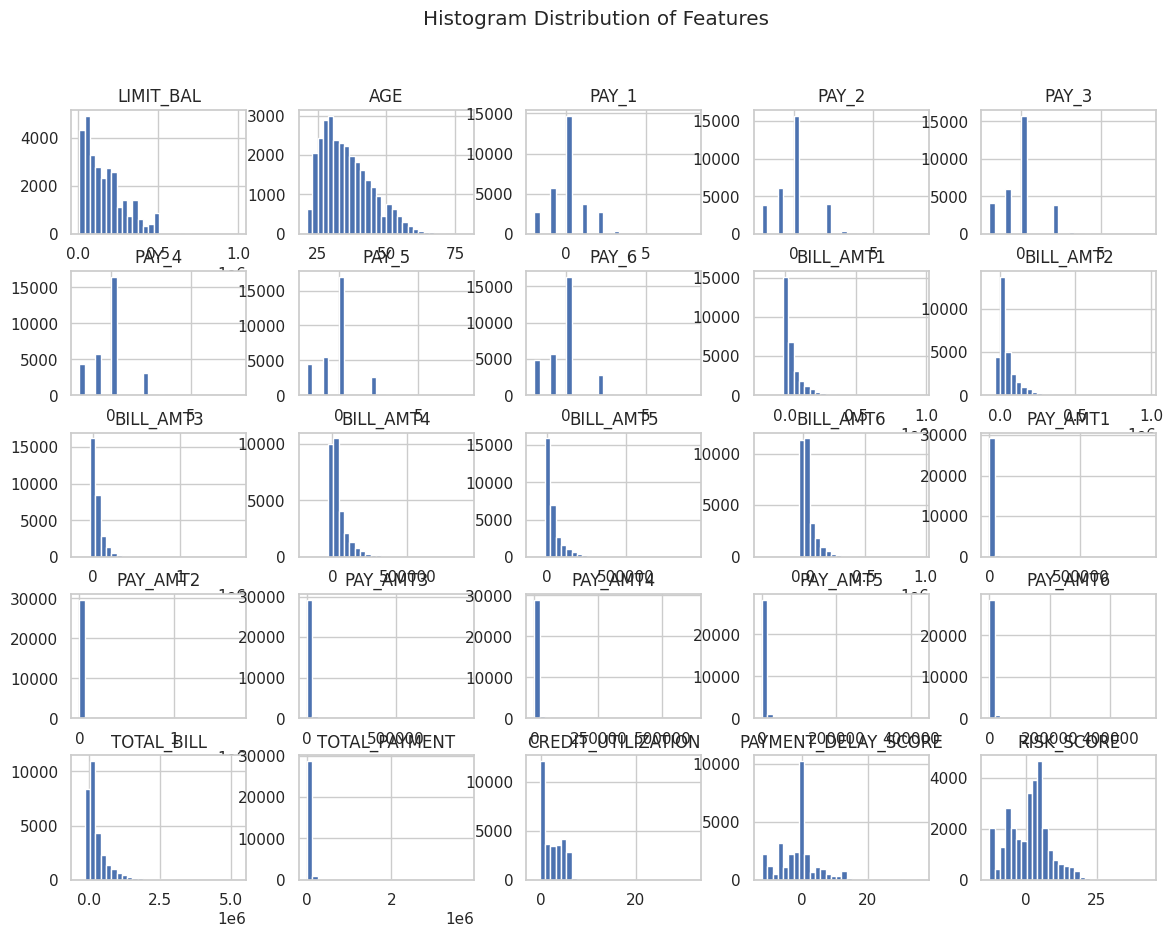

In [19]:
# Histogram
df.hist(bins=30, figsize=(14,10))
plt.suptitle("Histogram Distribution of Features")
plt.show()

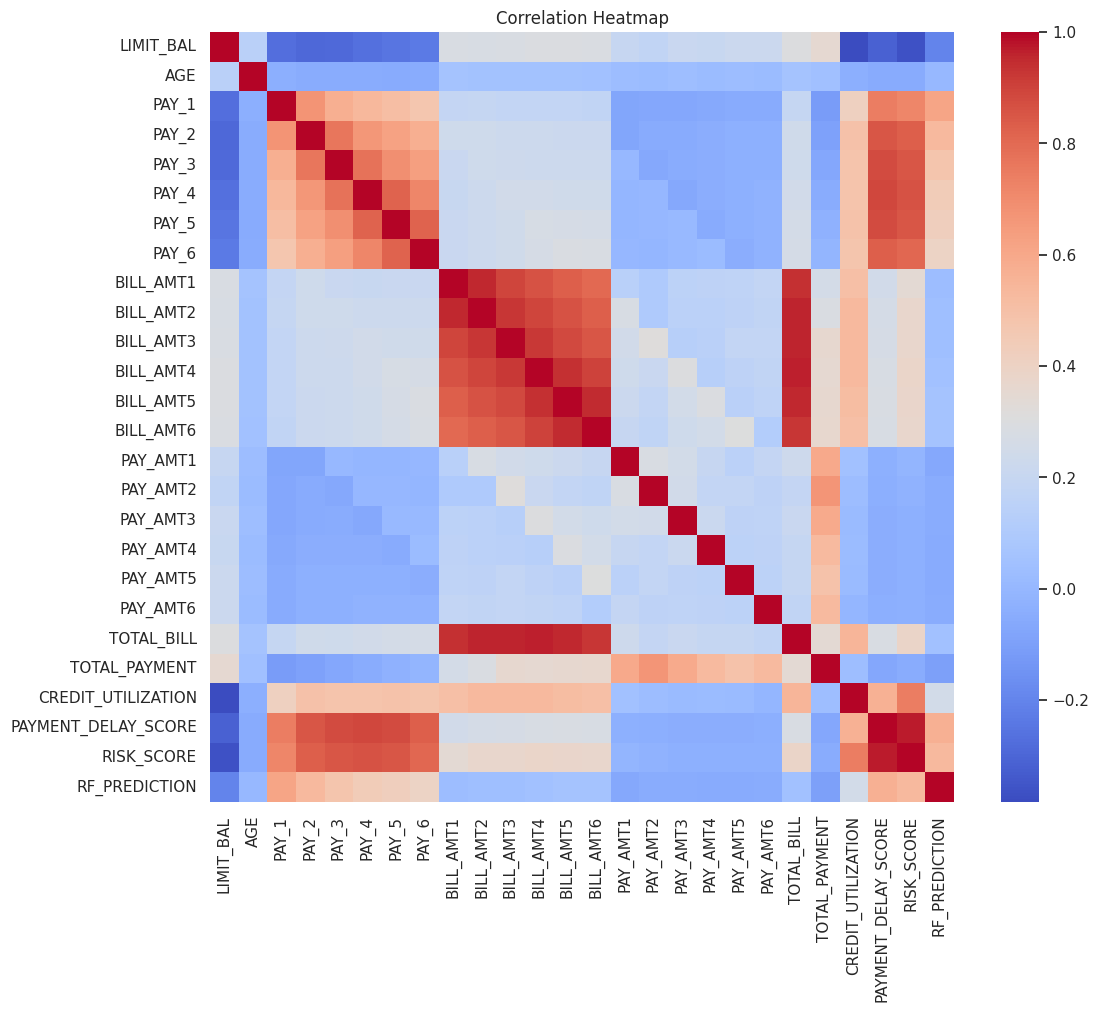

In [33]:
# Corelation Heatmap
plt.figure(figsize=(12,10))
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

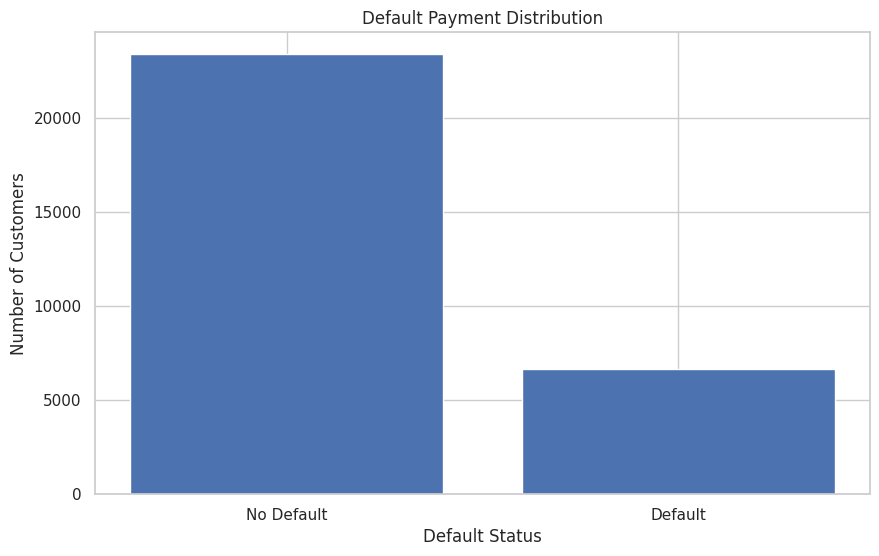

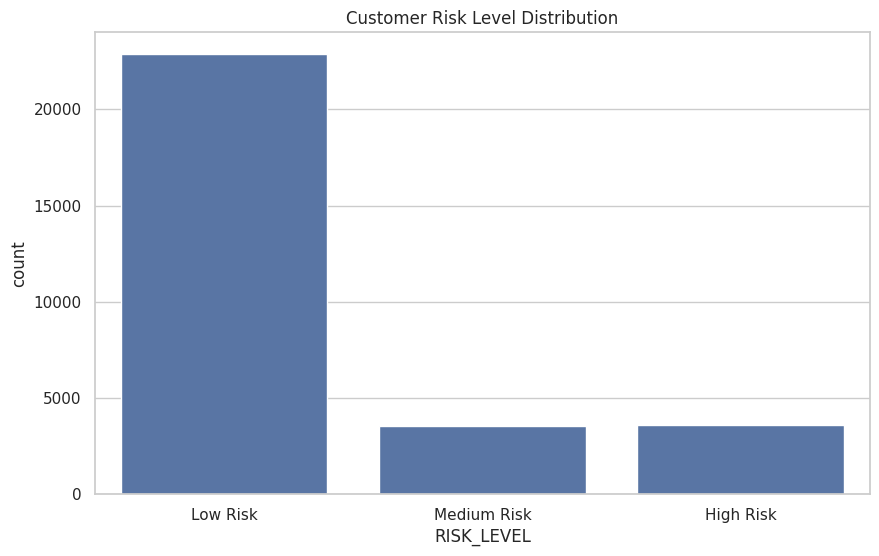

In [34]:
# Bar Graph
default_counts = df['DEFAULT'].value_counts()

plt.bar(['No Default','Default'], default_counts)
plt.title("Default Payment Distribution")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")
plt.show()

# Risk Level Distribution

sns.countplot(x='RISK_LEVEL', data=df)
plt.title("Customer Risk Level Distribution")
plt.show()


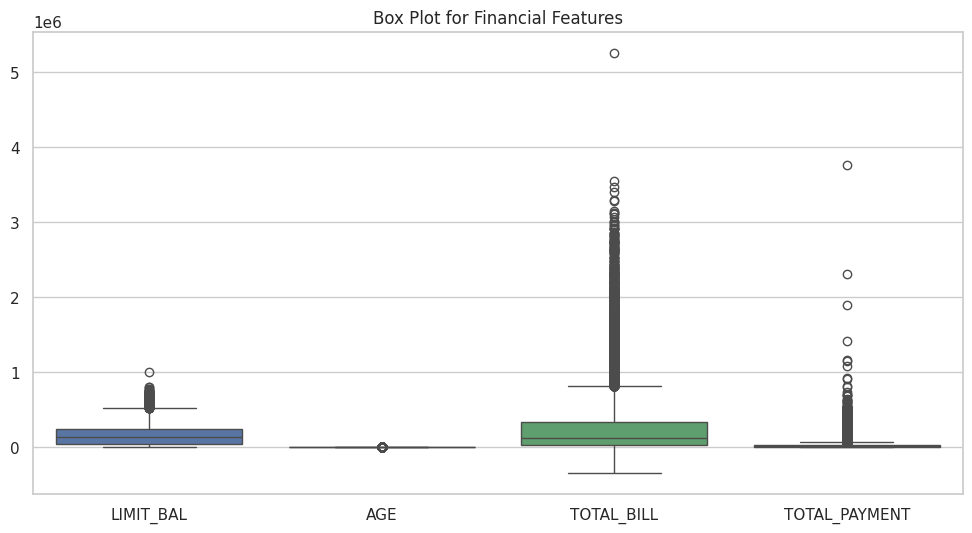

In [35]:
# Box Plot
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['LIMIT_BAL','AGE','TOTAL_BILL','TOTAL_PAYMENT']])
plt.title("Box Plot for Financial Features")
plt.show()


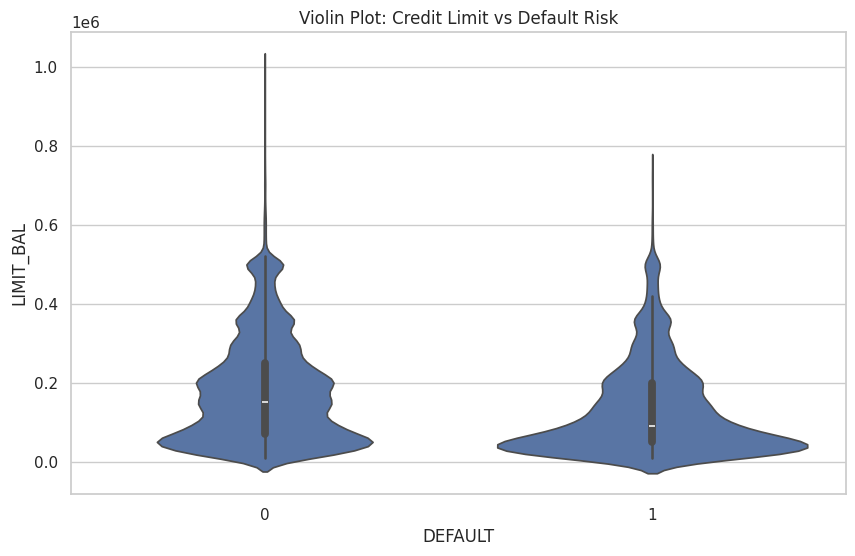

In [36]:
# violin plot
plt.figure(figsize=(10,6))
sns.violinplot(x='DEFAULT', y='LIMIT_BAL', data=df)
plt.title("Violin Plot: Credit Limit vs Default Risk")
plt.show()

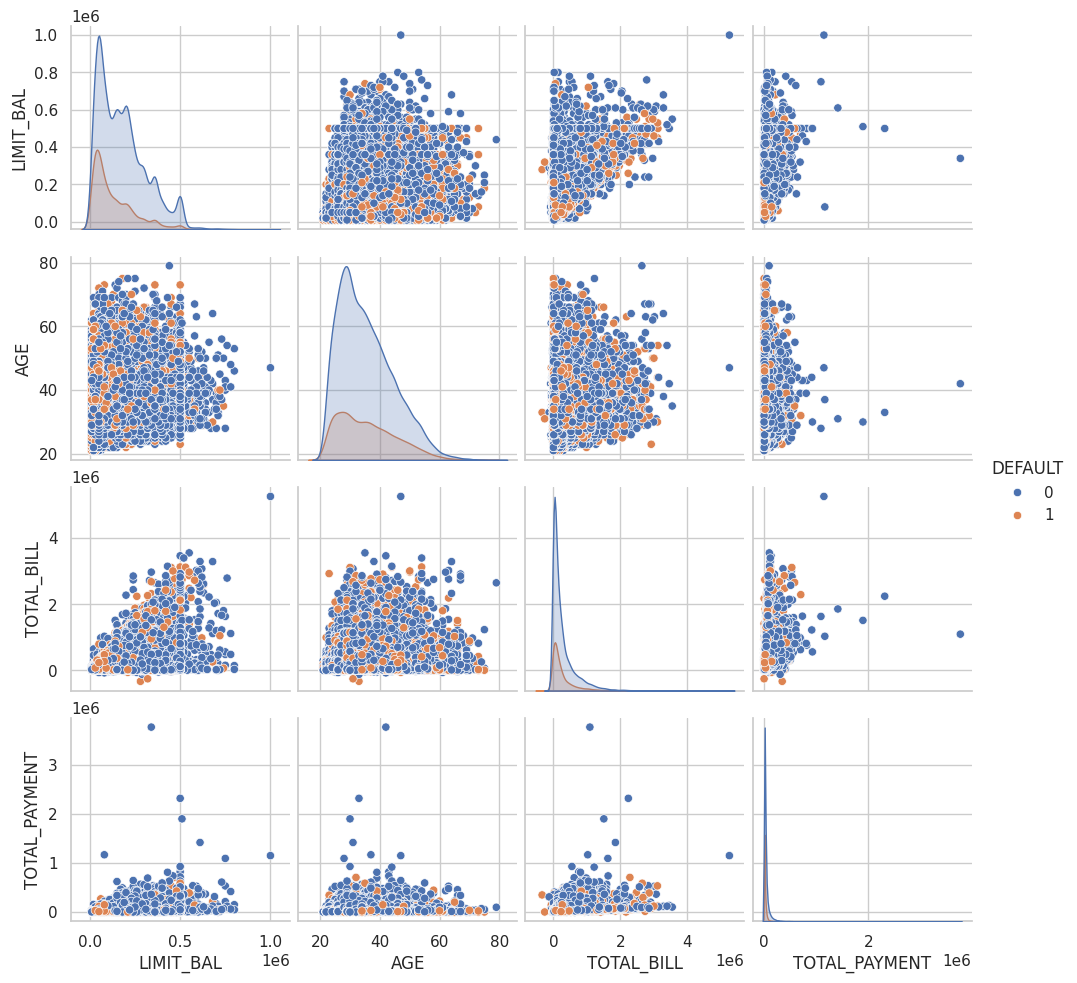

In [37]:
# Matrix plot
sns.pairplot(
    df[['LIMIT_BAL','AGE','TOTAL_BILL','TOTAL_PAYMENT','DEFAULT']],
    hue='DEFAULT'
)

plt.show()

In [39]:
# Risk monitoring output
print("\nRisk Level Summary")
print(df['RISK_LEVEL'].value_counts())

# Average credit utilization per risk group

risk_summary = df.groupby('RISK_LEVEL')['CREDIT_UTILIZATION'].mean()

print("\nAverage Credit Utilization by Risk Level")
print(risk_summary)


Risk Level Summary
RISK_LEVEL
Low Risk       22867
High Risk       3582
Medium Risk     3551
Name: count, dtype: int64

Average Credit Utilization by Risk Level
RISK_LEVEL
High Risk      3.729467
Low Risk       1.820520
Medium Risk    3.424348
Name: CREDIT_UTILIZATION, dtype: float64
